In [101]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage, HumanMessage
import operator

In [102]:
load_dotenv()

True

In [103]:
llm=ChatOpenAI(model="gpt-4o-mini")

In [104]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [105]:
structured_evaluator_llm = llm.with_structured_output(TweetEvaluation)

In [106]:
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal["approved", "need_improvement"]
    feedback: str
    iteration: int
    max_iteration: int 
    
    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [107]:
def generate_tweet(state: TweetState):
    
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    response = llm.invoke(messages).content

    return {'tweet': response, 'tweet_history': [response]}

In [108]:
def evaluate_tweet(state: TweetState):
    
    structured_llm = llm.with_structured_output(TweetEvaluation)

    messages = [
        SystemMessage(
            content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."
        ),
        HumanMessage(
            content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?
2. Humor – Did it genuinely make you smile, laugh, or chuckle?
3. Punchiness – Is it short, sharp, and scroll-stopping?
4. Virality Potential – Would people retweet or share it?
5. Format – Is it a well-formed tweet, not a setup-punchline joke, not a Q&A joke, and under 280 characters?

Auto-reject if:
- It is written in question-answer format
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- It ends with generic, throwaway, or deflating lines that weaken the humor

Respond only with:
- evaluation: "approved" or "needs_improvement"
- feedback: one paragraph explaining the strengths and weaknesses
"""
        )
    ]

    response = structured_llm.invoke(messages)

    return {
        "evaluation": response.evaluation,
        "feedback": response.feedback,
        "feedback_history": [response.feedback]
    }

In [109]:
def optimized_tweet(state: TweetState):
    
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [110]:
def route_evaluation(state: TweetState):
    
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'need_improvement'

In [111]:
graph=StateGraph(TweetState)
graph.add_node("generate_tweet", generate_tweet)
graph.add_node("evaluate_tweet", evaluate_tweet)
graph.add_node("optimized_tweet", optimized_tweet)

graph.add_edge(START, "generate_tweet")
graph.add_edge("generate_tweet","evaluate_tweet")
graph.add_conditional_edges("evaluate_tweet",route_evaluation, {'approved':END, "need_improvement": "optimized_tweet"})
graph.add_edge("optimized_tweet", "evaluate_tweet")


In [112]:
workflow=graph.compile()

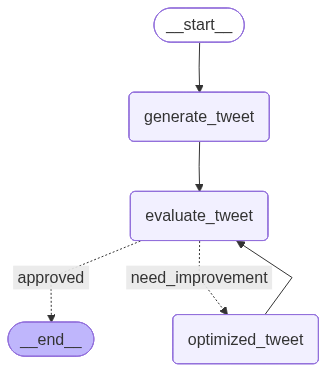

In [113]:
workflow

In [114]:
initial_state = {
    "topic": "srhberhb",
    "iteration": 1,
    "max_iteration": 5
}
final_state = workflow.invoke(initial_state)

In [115]:
final_state

{'topic': 'srhberhb',
 'tweet': 'Just tried to pronounce "srhberhb" out loud and the whole room went silent. I think I either summoned a demon or just invented a new language for all my awkward social interactions. At least I’ve finally mastered the art of confusing everyone. 🌪️ #LivingTheStruggle',
 'evaluation': 'approved',
 'feedback': "This tweet showcases originality with its unique attempt at creating a nonsensical word that humorously addresses awkward social situations. The humor is effective, bringing a lighthearted chuckle about the absurdity of the experience. The format is well-structured, fitting comfortably under the character limit and avoiding cliche setups. It’s punchy enough to catch attention on a crowded feed, and the relatable theme of social awkwardness enhances its virality potential, encouraging sharing. Overall, it's a solid, engaging tweet that accomplishes its goals.",
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['Just tried to pronounce "srhberhb